In [1]:
import os
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D
import matplotlib.pyplot as plt


2026-02-23 10:24:06.710024: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 10:24:06.824304: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 10:24:11.201526: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 10:24:17.430498: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:


image_dir = "Project/Image/ALL_P"  # All Image directory 
image_size = (32,32)
batch_size = 32
num_classes = 2


image_files = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".jpeg", ".png"))]
random.shuffle(image_files) # Shuffle the image files for random distribution
labels = [f.split("_")[0] for f in image_files]  # extract label from filename

df = pd.DataFrame({
    "filename": image_files,
    "class": labels
})

# Splitting dataframe for training, validation, and testing(1 time i split for val and test only)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["class"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["class"], random_state=42)


datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    directory=image_dir,
    x_col="filename",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="sparse"
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    directory=image_dir,
    x_col="filename",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="sparse"
)

test_gen = datagen.flow_from_dataframe(
    test_df,
    directory=image_dir,
    x_col="filename",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# Convert class labels to integers (Keep them as single integers, not one-hot encoded vectors)
inputs = Input(shape=(32, 32, 3))
x = Conv2D(8, (3, 3), activation='relu')(inputs)
x = Conv2D(8, (3, 3), activation='relu')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(train_gen, epochs=10, validation_data=val_gen)

loss, accuracy = model.evaluate(test_gen)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Found 800 validated image filenames belonging to 2 classes.
Found 100 validated image filenames belonging to 2 classes.
Found 100 validated image filenames belonging to 2 classes.


2026-02-23 10:24:22.218444: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,986 (1.60 MB)

 Trainable params: 418,986 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

/home/apd/code/CSE_Lab/CSE_4_1/myenv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6313 - loss: 0.6451 - val_accuracy: 0.7200 - val_loss: 0.5330
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8700 - loss: 0.3539 - val_accuracy: 0.9400 - val_loss: 0.1872
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9688 - loss: 0.1156 - val_accuracy: 0.9700 - val_loss: 0.0881
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9837 - loss: 0.0648 - val_accuracy: 0.9700 - val_loss: 0.1297
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9850 - loss: 0.0675 - val_accuracy: 0.9400 - val_loss: 0.1061
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9925 - loss: 0.0359 - val_accuracy: 0.9600 - val_loss: 0.0915
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9937 - loss: 0.0262 - val_accuracy: 0.9500 - val_loss: 0.1931
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9912 - loss: 0.0395 - val_accuracy: 0.9800 - v

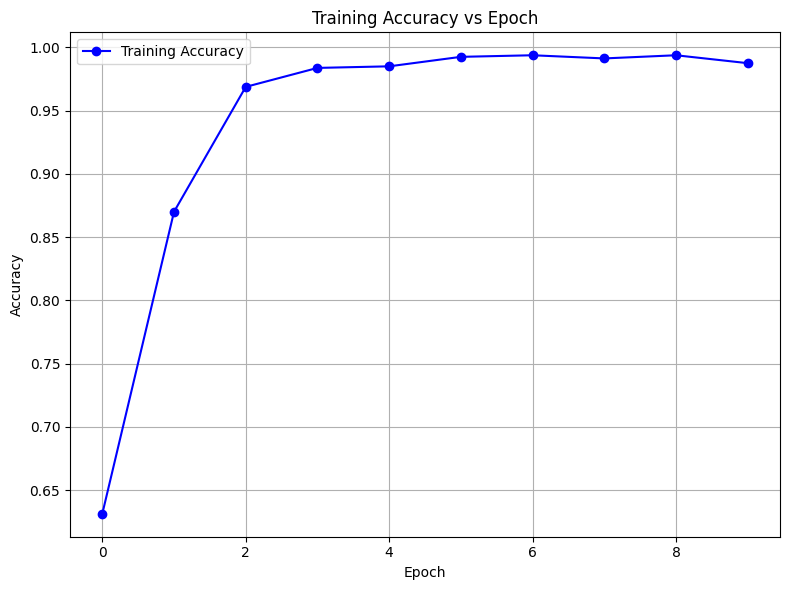

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='blue')
plt.title('Training Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


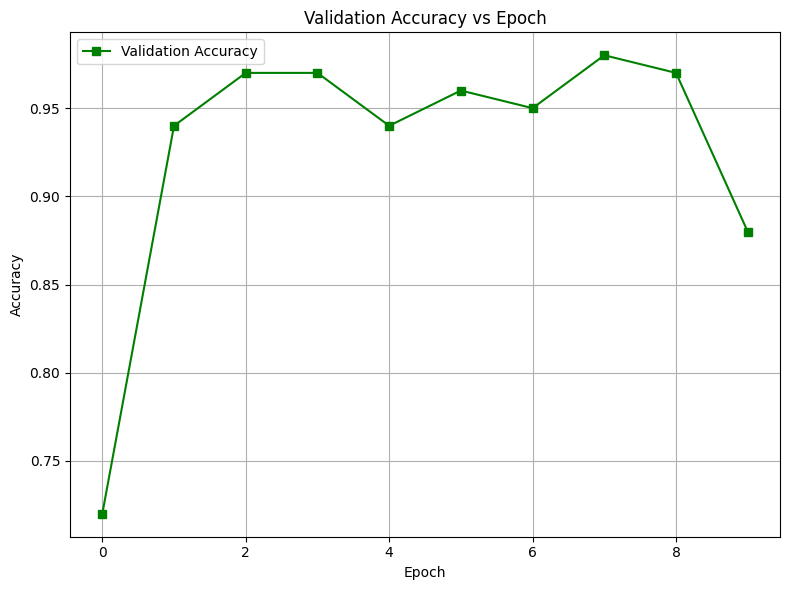

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='green')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import matplotlib.pyplot as plt
import numpy as np


test_images, test_labels = next(test_generator)  # one batch of test data
pred_probs = model.predict(test_images)          # predict probabilities
pred_labels = np.argmax(pred_probs, axis=1)      # get predicted class indices


class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    if(i >= len(test_images)):
        break
    img = test_images[i]
    true_label = int(test_labels[i])
    pred_label = pred_labels[i]
    confidence = pred_probs[i][pred_label]  # confidence of predicted class
    
    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred_label]} ({confidence:.2f})\nTrue: {class_names[true_label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


NameError: name 'test_generator' is not defined